In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["pdf.use14corefonts"] = True
mpl.rcParams['pdf.fonttype'] = 42
import numpy as np
import pandas as pd
import random
import scanpy as sc
import seaborn as sns

import os
main_path = os.getcwd()

import sys
sys.path.append(main_path)

from analysis.libraries.data_processing import match_core_to_ACA

In [ ]:
adata = ad.read_h5ad(os.path.append(main_path, 'data/LATTICeA_io_adata_ssl_leiden_224px_fold0.h5ad'))
adata.obs

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,CKPAN,111.3728,222.7456,222.7456,334.1184,2
1,8502.780534,-47222.466136,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,106.730014,199.409334,-148.094936,0,0,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
2,8510.929662,-47224.074935,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,42.000237,207.558462,-149.703735,0,9,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
3,8517.623256,-47224.496313,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,72.882764,214.252056,-150.125113,0,0,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
4,8522.685445,-47229.076912,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Stroma,35.082551,219.314245,-154.705712,1,8,CD68,111.3728,222.7456,111.3728,222.7456,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815638,8311.875731,-53930.612326,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,92.153461,717.504531,-1115.241126,2,4,CD4,1113.7280,1225.1008,668.2368,779.6096,NaN
16815639,8433.799791,-53929.827897,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,58.059151,839.428591,-1114.456697,1,8,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN
16815640,8299.651795,-53932.267364,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,98.577027,705.280595,-1116.896164,1,8,CD68,1113.7280,1225.1008,668.2368,779.6096,NaN
16815641,8411.888971,-53932.588400,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Tumour,104.259412,817.517771,-1117.217200,1,2,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN


In [ ]:
cores_df = pd.read_csv(os.path.join(main_path, 'data/metadata/tma-core-metadata.csv'))    
bioclavis_cores = adata.obs['Core_ID'].unique()
bioclavis_core_dict = dict()

for core in bioclavis_cores:
    bioclavis_core_dict[core] = match_core_to_ACA(core, cores_df)

adata = adata[~adata.obs['leiden'].isna()]
adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,CKPAN,111.3728,222.7456,222.7456,334.1184,2
27,8742.773201,-47095.090102,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,76.835727,439.402001,-20.718902,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3
28,8733.498735,-47095.239798,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,51.388525,430.127535,-20.868598,3,1,Negative,0.0000,111.3728,334.1184,445.4912,3
29,8725.386080,-47099.971000,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,85.235775,422.014880,-25.599800,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3
30,8732.694222,-47103.156256,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,60.035633,429.323022,-28.785056,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815631,8290.138303,-53925.794981,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,86.471076,695.767103,-1110.423781,1,8,CD68,1002.3552,1113.7280,668.2368,779.6096,1
16815632,8321.851902,-53924.864889,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,116.859483,727.480702,-1109.493689,3,8,CD68,1002.3552,1113.7280,668.2368,779.6096,1
16815633,8468.645055,-53925.123736,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,136.624300,874.273855,-1109.752536,1,2,CD68,1002.3552,1113.7280,779.6096,890.9824,15
16815634,8337.052047,-53925.889475,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,64.235656,742.680847,-1110.518275,3,1,Negative,1002.3552,1113.7280,668.2368,779.6096,1


In [5]:
adata.obs['tile'] = adata.obs.apply(lambda row: "_".join([str(row['y_start']), str(row['y_stop']), str(row['x_start']), str(row['x_stop'])]), axis=1)
adata.obs

/tmp/ipykernel_2991413/1540152671.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['tile'] = adata.obs.apply(lambda row: "_".join([str(row['y_start']), str(row['y_stop']), str(row['x_start']), str(row['x_stop'])]), axis=1)


,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden,tile
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,CKPAN,111.3728,222.7456,222.7456,334.1184,2,111.3728_222.7456_222.7456_334.1184
27,8742.773201,-47095.090102,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,76.835727,439.402001,-20.718902,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912
28,8733.498735,-47095.239798,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,51.388525,430.127535,-20.868598,3,1,Negative,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912
29,8725.386080,-47099.971000,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,85.235775,422.014880,-25.599800,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912
30,8732.694222,-47103.156256,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,60.035633,429.323022,-28.785056,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815631,8290.138303,-53925.794981,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,86.471076,695.767103,-1110.423781,1,8,CD68,1002.3552,1113.7280,668.2368,779.6096,1,1002.3552_1113.728_668.2368_779.6096
16815632,8321.851902,-53924.864889,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,116.859483,727.480702,-1109.493689,3,8,CD68,1002.3552,1113.7280,668.2368,779.6096,1,1002.3552_1113.728_668.2368_779.6096
16815633,8468.645055,-53925.123736,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,136.624300,874.273855,-1109.752536,1,2,CD68,1002.3552,1113.7280,779.6096,890.9824,15,1002.3552_1113.728_779.6096_890.9824
16815634,8337.052047,-53925.889475,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,64.235656,742.680847,-1110.518275,3,1,Negative,1002.3552,1113.7280,668.2368,779.6096,1,1002.3552_1113.728_668.2368_779.6096


In [6]:
adata.obs['samples'] = adata.obs['Core_ID'].map(bioclavis_core_dict)
adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden,tile,samples
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,CKPAN,111.3728,222.7456,222.7456,334.1184,2,111.3728_222.7456_222.7456_334.1184,ACA_1067
27,8742.773201,-47095.090102,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,76.835727,439.402001,-20.718902,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912,ACA_1067
28,8733.498735,-47095.239798,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,51.388525,430.127535,-20.868598,3,1,Negative,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912,ACA_1067
29,8725.386080,-47099.971000,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,85.235775,422.014880,-25.599800,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912,ACA_1067
30,8732.694222,-47103.156256,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,60.035633,429.323022,-28.785056,0,0,CKPAN,0.0000,111.3728,334.1184,445.4912,3,0.0_111.3728_334.1184_445.4912,ACA_1067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815631,8290.138303,-53925.794981,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,86.471076,695.767103,-1110.423781,1,8,CD68,1002.3552,1113.7280,668.2368,779.6096,1,1002.3552_1113.728_668.2368_779.6096,ACA_0936
16815632,8321.851902,-53924.864889,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,116.859483,727.480702,-1109.493689,3,8,CD68,1002.3552,1113.7280,668.2368,779.6096,1,1002.3552_1113.728_668.2368_779.6096,ACA_0936
16815633,8468.645055,-53925.123736,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,136.624300,874.273855,-1109.752536,1,2,CD68,1002.3552,1113.7280,779.6096,890.9824,15,1002.3552_1113.728_779.6096_890.9824,ACA_0936
16815634,8337.052047,-53925.889475,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,64.235656,742.680847,-1110.518275,3,1,Negative,1002.3552,1113.7280,668.2368,779.6096,1,1002.3552_1113.728_668.2368_779.6096,ACA_0936


In [ ]:
adata.obs['cell_lineage'].replace({'Negative':'Unclassifiable'}, inplace=True)

## Cell frequency

In [8]:
frequencies_list = []

grouped = adata.obs.groupby(['leiden', 'Core_ID', 'tile'])

for (cluster, core, tile), tile_df in grouped:
    num_cells = tile_df.shape[0]
    cell_frequencies = tile_df['cell_lineage'].value_counts().to_frame().T 
    cell_frequencies['core'] = core
    cell_frequencies['tile'] = tile
    cell_frequencies['leiden'] = cluster
    frequencies_list.append(cell_frequencies)

cluster_cell_frequencies = pd.concat(frequencies_list).reset_index()
cluster_cell_frequencies

,index,Unclassifiable,CD68,CKPAN,SMA,CD4,CD8,core,tile,leiden
0,cell_lineage,37,24,10,4,1,0,01-02-A,334.1184_445.4912_668.2368_779.6096,0
1,cell_lineage,15,9,2,7,5,6,01-03-H,668.2368_779.6096_445.4912_556.864,0
2,cell_lineage,38,12,10,4,1,9,01-05-A,779.6096_890.9824_890.9824_1002.3552,0
3,cell_lineage,49,14,14,2,10,14,01-06-A,779.6096_890.9824_334.1184_445.4912,0
4,cell_lineage,24,24,12,3,0,0,01-06-C,556.864_668.2368_1002.3552_1113.728,0
...,...,...,...,...,...,...,...,...,...,...
191646,cell_lineage,64,2,0,2,1,2,21-13-I,111.3728_222.7456_445.4912_556.864,27
191647,cell_lineage,72,1,0,1,1,0,21-14-I,779.6096_890.9824_890.9824_1002.3552,27
191648,cell_lineage,54,7,0,0,0,2,21-15-E,0.0_111.3728_445.4912_556.864,27
191649,cell_lineage,81,2,1,0,0,0,21-15-E,111.3728_222.7456_334.1184_445.4912,27


### Cell frequency by compartment

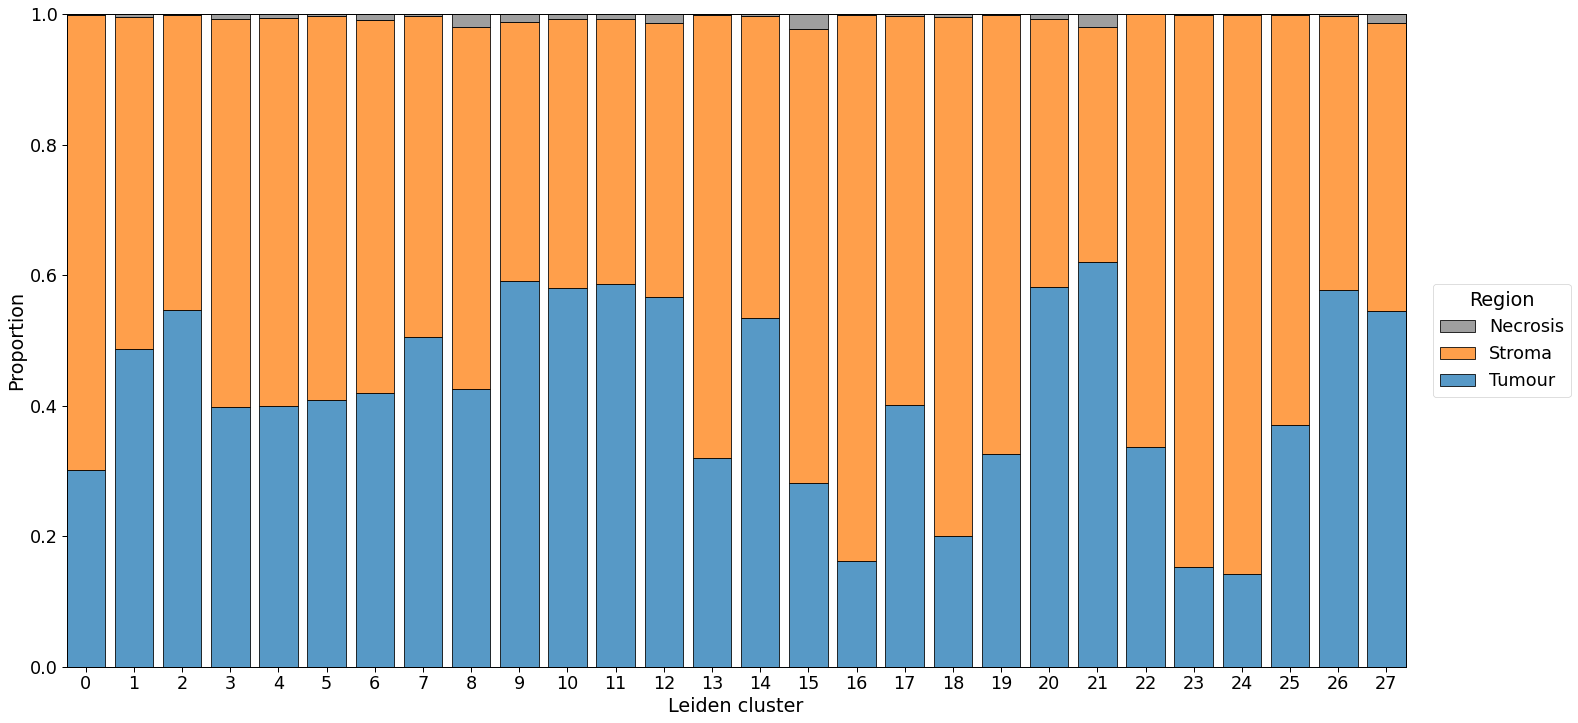

In [9]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(24,12))

sns.histplot(adata.obs, x='leiden', hue='Region', stat='proportion', discrete=True, multiple='fill', 
             palette={'Tumour':sns.color_palette('tab10')[0], 'Stroma':sns.color_palette('tab10')[1], 'Necrosis':sns.color_palette('tab10')[7]},
             shrink=.8,   ax=ax)

ax.set_ylabel('Proportion')
ax.set_xlabel('Leiden cluster')
sns.move_legend(ax, loc='right', bbox_to_anchor=(1.13, 0.5))

In [14]:
adata.obs = adata.obs.replace({'CKPAN':'panCK'})

### Cell frequency by phenotype

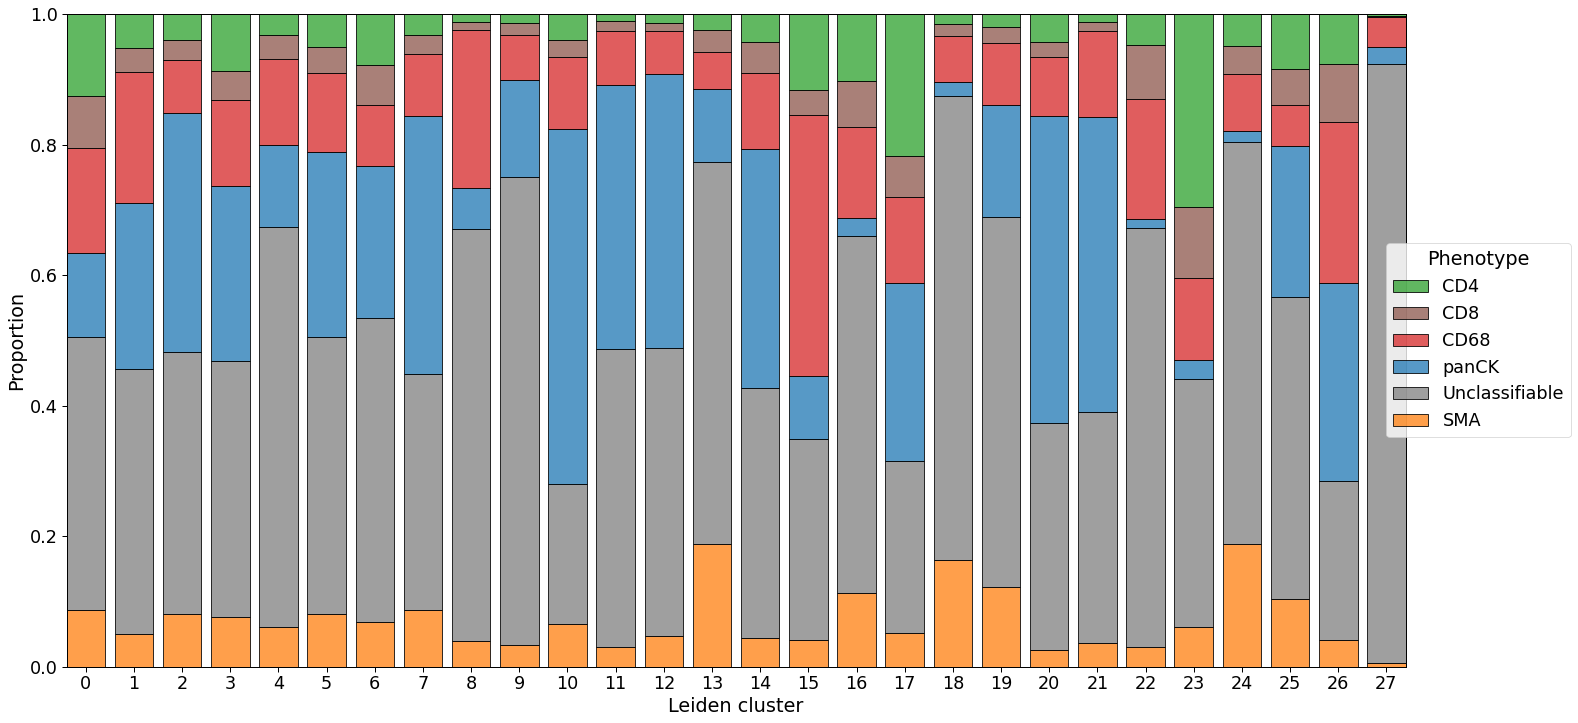

In [15]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(24,12))

sns.histplot(adata.obs, x='leiden', hue='cell_lineage', stat='proportion', discrete=True, multiple='fill', 
             palette={'panCK':sns.color_palette('tab10')[0], 'SMA':sns.color_palette('tab10')[1], 'CD4':sns.color_palette('tab10')[2],
                      'CD8':sns.color_palette('tab10')[5], 'CD68':sns.color_palette('tab10')[3], 'Unclassifiable':sns.color_palette('tab10')[7]},
             shrink=.8, ax=ax)

ax.set_ylabel('Proportion')
ax.set_xlabel('Leiden cluster')
sns.move_legend(ax, loc='right', bbox_to_anchor=(1.13, 0.5), title='Phenotype')

<Axes: xlabel='leiden', ylabel='count'>

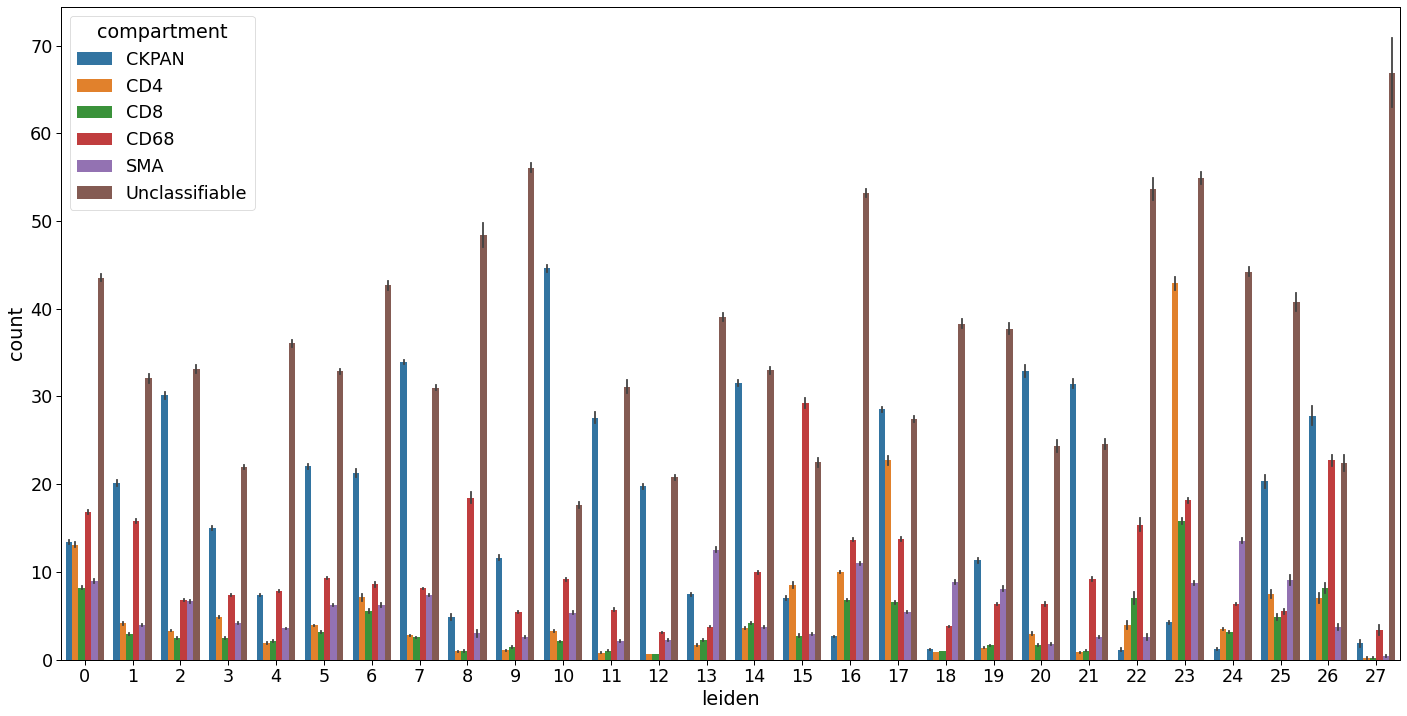

In [17]:
frequencies_melt = pd.melt(cluster_cell_frequencies, id_vars=['core', 'tile', 'leiden'], value_name='count', value_vars=['CKPAN', 'CD4', 'CD8', 'CD68', 'SMA', 'Unclassifiable'], var_name='compartment')

fig, ax = plt.subplots(figsize=(24,12))
sns.barplot(frequencies_melt, x = 'leiden', y = 'count', hue = 'compartment', errorbar='ci', ax=ax)


In [20]:
cluster_cell_frequencies = cluster_cell_frequencies.rename(columns={'CKPAN':'panCK'})

In [23]:
import matplotlib as mpl
mpl.rcParams["pdf.use14corefonts"] = True
mpl.rcParams['pdf.fonttype'] = 42
sns.set_context("paper", font_scale=3.0)

/tmp/ipykernel_2991413/39953516.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cluster_mean_frequencies = cluster_cell_frequencies.groupby(['leiden']).mean().reset_index().set_index('leiden')


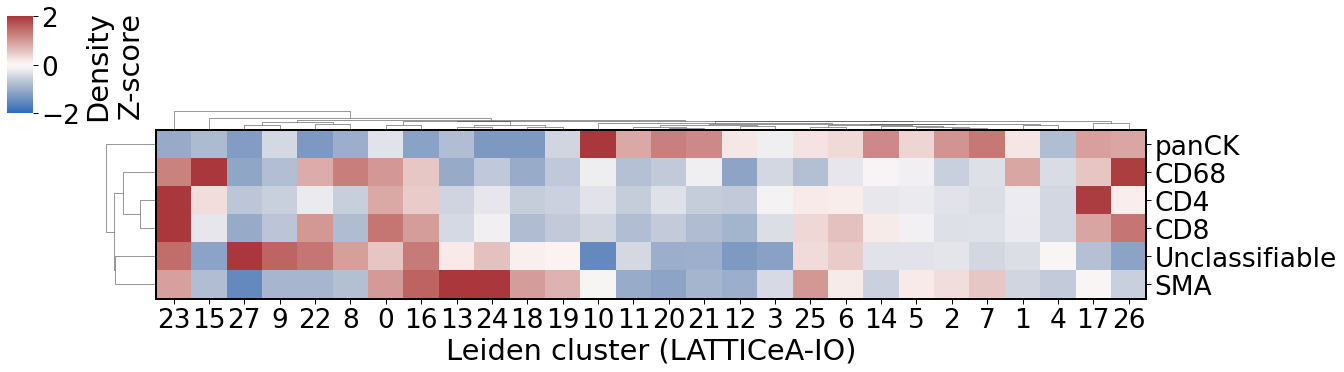

In [ ]:
cluster_mean_frequencies = cluster_cell_frequencies.groupby(['leiden']).mean().reset_index().set_index('leiden')
cluster_mean_frequencies = cluster_mean_frequencies.T

from matplotlib.patches import Rectangle

g = sns.clustermap(cluster_mean_frequencies,
               z_score=0,
               vmin=-2,
               vmax=2,
               cmap='vlag',
               linewidths=.2,
               xticklabels=1,
               dendrogram_ratio=(.05, .1),
               cbar_pos=(-0.05, .895, .02, .3),
               cbar_kws={'label':'Density\nZ-score'},
               figsize=(18,4.5))

g.ax_heatmap.collections[0].set_edgecolor('black')
g.ax_heatmap.collections[0].set_linewidth(.0)

n_rows, n_cols = cluster_mean_frequencies.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_xlabel('Leiden cluster (LATTICeA-IO)')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=0);

plt.show()

In [ ]:
cluster_mean_frequencies.to_csv(os.path.join(main_path, 'data/results/io_cluster_mean_cell_frequencies.csv'))